# Улучшенный алгоритм DMDc: реализация и анализ

**Источник:** Nedzhibov, G. *An Improved Approach for Implementing Dynamic 
Mode Decomposition with Control.* Computation, 2023, 11(10), 201.

---

## Структура проекта

| Шаг | Содержание |
|-----|-----------|
| 1 | Генерация данных (Лотка–Вольтерра, Лоренц) |
| 2 | Реализация стандартного DMDc (Algorithm 1) |
| 3 | Реализация улучшенного DMDc (Algorithm 3) |
| 4 | Метрики качества и визуализация |
| 5 | Сравнение с PyDMD |

In [86]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
# Настройка графиков
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'legend.fontsize': 10,
})

### 1.1 Система Лотки–Вольтерры

Рассматривается классическая модель **хищник–жертва** с внешним управляющим 
воздействием $u(t)$:

$$\dot{x}_1 = \alpha\,x_1 - \beta\,x_1\,x_2$$
$$\dot{x}_2 = -\gamma\,x_2 + \delta\,x_1\,x_2 + u(t)$$

где:
- $x_1$ — численность жертвы
- $x_2$ — численность хищника  
- $u(t)$ — управляющее воздействие (только на уравнение хищника)

**Параметры из статьи Nedzhibov (2023):**

| Параметр | Значение | Смысл |
|----------|----------|-------|
| $\alpha$ | $1/2$ | Скорость роста жертвы |
| $\beta$ | $1/40$ | Эффект хищничества на жертву |
| $\gamma$ | $1/2$ | Скорость вымирания хищника |
| $\delta$ | $1/200$ | Рост хищника за счёт жертвы |
| $\mathbf{x}_0$ | $(60,\,50)^T$ | Начальное условие |
| $u(t)$ | $(2\sin t\,\sin(t/10))^2$ | Управление |
| $\Delta t$ | $0.1$ | Шаг между снимками |
| $m$ | $500$ | Число снимков (столбцов в $X$, $X'$, $\Upsilon$) |

Без управления система демонстрирует **предельный цикл** — популяции 
колеблются бесконечно. Управление уводит траекторию к равновесной точке
$\mathbf{x}_{eq} = (\gamma/\delta,\;\alpha/\beta)^T$.

In [87]:
# ── Параметры системы ──
alpha = 1/2
beta  = 1/40
gamma = 1/2
delta = 1/200
x0_lv = np.array([60.0, 50.0]) 
# -- уравнение управления -- 
def u_lv(t):
    return (2*np.sin(t)*np.sin(t/10))**2

def lotka_volterra(t, x):
    """
    Система Лотки–Вольтерры с управлением u(t).
    """
    x1 = x[0]
    x2 = x[1]
    dx1 = alpha * x1 - beta  * x1 * x2
    dx2 = delta * x1 * x2 - gamma * x2 + u_lv(t)
    return [dx1, dx2]

#### Численное интегрирование

Интегрируем систему на отрезке $[0,\,50]$ с шагом снимков $\Delta t = 0.1$,  
получая $m+1 = 501$ точку. Из них формируем матрицы снимков:

$$X = [\mathbf{x}_0, \ldots, \mathbf{x}_{499}] \in \mathbb{R}^{2\times 500}, \qquad
X' = [\mathbf{x}_1, \ldots, \mathbf{x}_{500}] \in \mathbb{R}^{2\times 500}, \qquad
\Upsilon = [u_0, \ldots, u_{499}] \in \mathbb{R}^{1\times 500}$$

Используем высокую точность интегрирования (`rtol=1e-10`, `atol=1e-12`),  
чтобы избежать накопления численной ошибки.

In [88]:
dt = 0.1
snapshot = 1001
t_end = (snapshot-1)*dt
t_eval_lv = np.linspace(0, t_end, snapshot)

In [89]:
sol_lv = solve_ivp(fun=lotka_volterra,y0=x0_lv, method='LSODA', t_span=[0,t_end] , t_eval= t_eval_lv, rtol = 1e-10, atol = 1e-12)
print(f"\nИнтегрирование: {'успешно ✓' if sol_lv.success else 'ОШИБКА ✗'}")
print(f"Размер решения: {sol_lv.y.shape}  (n_states × n_snapshots)")


Интегрирование: успешно ✓
Размер решения: (2, 1001)  (n_states × n_snapshots)


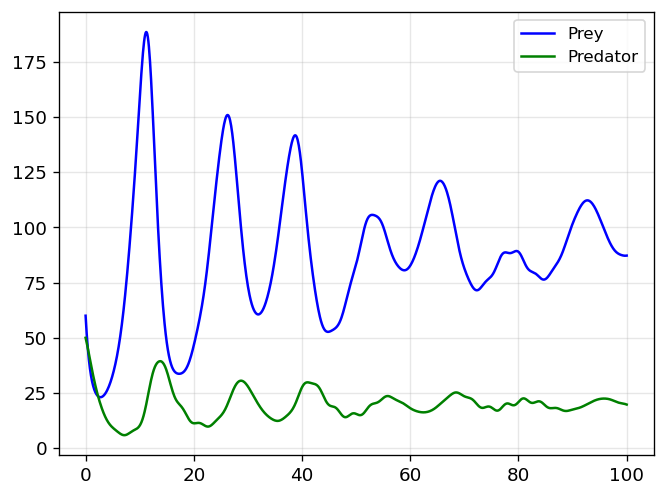

In [90]:
plt.figure()
plt.plot( sol_lv.t, sol_lv.y[0], color = 'blue', label = "Prey")
plt.plot( sol_lv.t, sol_lv.y[1], color = 'green', label = "Predator")
plt.legend()

#### Формирование матриц снимков

In [91]:
# ── Матрицы снимков ──
X_lv  = sol_lv.y[:, :-1]                          # (2, 1000) — состояния "сейчас"
Xp_lv = sol_lv.y[:, 1:]                           # (2, 1000) — состояния "потом"
U_lv  = u_lv(t_eval_lv[:-1]).reshape(1, -1)       # (1, 500) — управление
print("Матрицы снимков (Лотка–Вольтерра):")
print(f"  X  : {X_lv.shape}  — состояния x_0 ... x_499")
print(f"  X' : {Xp_lv.shape}  — состояния x_1 ... x_500")
print(f"  Υ  : {U_lv.shape}  — управление u_0 ... u_499")
# ── Расширенная матрица Omega (понадобится в алгоритмах) ───────────────────
Omega_lv = np.vstack([X_lv, U_lv])   # (3, 500) = (n+l, m)
print(f"\n  Ω  : {Omega_lv.shape}  — расширенная матрица [X; Υ]")

Матрицы снимков (Лотка–Вольтерра):
  X  : (2, 1000)  — состояния x_0 ... x_499
  X' : (2, 1000)  — состояния x_1 ... x_500
  Υ  : (1, 1000)  — управление u_0 ... u_499

  Ω  : (3, 1000)  — расширенная матрица [X; Υ]


#### Визуализация данных

Строим три графика:
1. **Динамика популяций** во времени — воспроизводим Figure 1 из статьи
2. **Фазовый портрет** — траектория в пространстве $(x_1, x_2)$
3. **Управляющий сигнал** $u(t)$

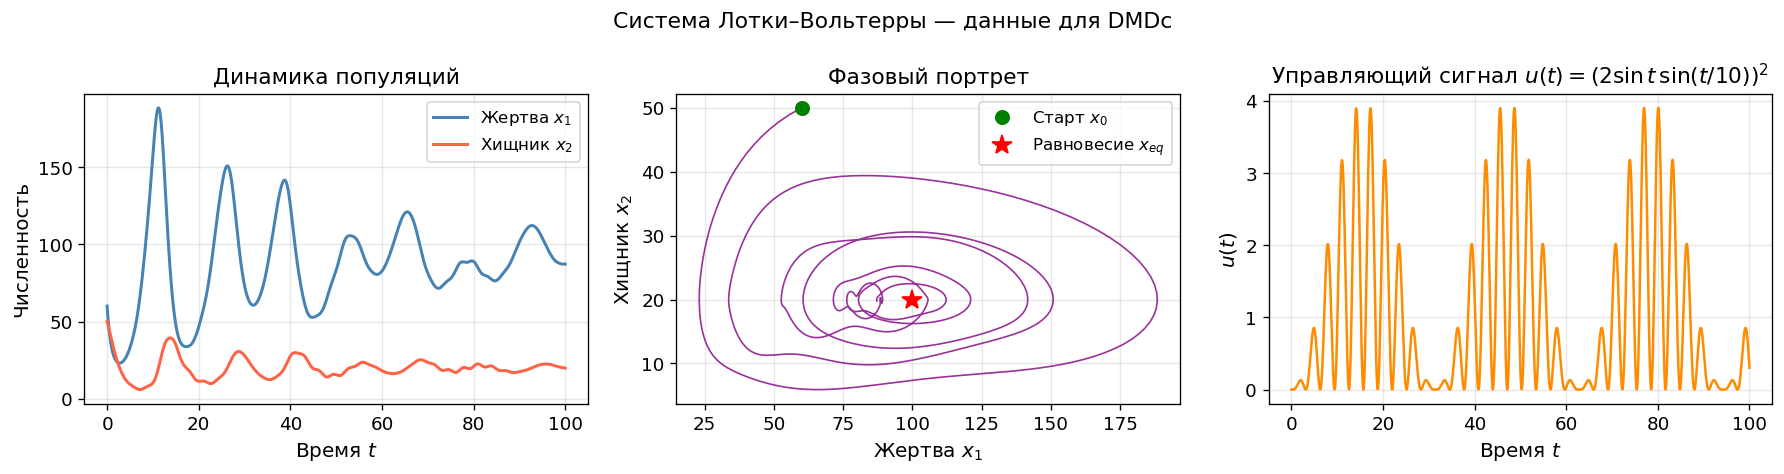

In [92]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# ── График 1: динамика популяций ───────────────────────────────────
axes[0].plot(t_eval_lv, sol_lv.y[0],
             color='steelblue', lw=1.8, label='Жертва $x_1$')
axes[0].plot(t_eval_lv, sol_lv.y[1],
             color='tomato', lw=1.8, label='Хищник $x_2$')
axes[0].set_xlabel('Время $t$')
axes[0].set_ylabel('Численность')
axes[0].set_title('Динамика популяций')
axes[0].legend()

# ── График 2: фазовый портрет ──────────────────────────────────────
axes[1].plot(sol_lv.y[0], sol_lv.y[1],
             color='purple', lw=1.0, alpha=0.8)
axes[1].plot(*x0_lv, 'go', ms=8,  label='Старт $x_0$',          zorder=5)
axes[1].plot(*np.array([gamma/delta, alpha/beta]),  'r*', ms=12, label='Равновесие $x_{eq}$',  zorder=5)
axes[1].set_xlabel('Жертва $x_1$')
axes[1].set_ylabel('Хищник $x_2$')
axes[1].set_title('Фазовый портрет')
axes[1].legend()

# ── График 3: управляющий сигнал ───────────────────────────────────
axes[2].plot(t_eval_lv, u_lv(t_eval_lv),
             color='darkorange', lw=1.5)
axes[2].set_xlabel('Время $t$')
axes[2].set_ylabel('$u(t)$')
axes[2].set_title('Управляющий сигнал $u(t)=(2\\sin t\\,\\sin(t/10))^2$')

plt.suptitle(
    'Система Лотки–Вольтерры — данные для DMDc'
)
plt.tight_layout()
plt.savefig('/Users/ruslan/Desktop/Education Skoltech/Data-Driven modelling/projects/lv_data.png', dpi=150, bbox_inches='tight')
plt.show()

### 1.2 Система Лоренца

Хаотическая система с управлением:

$$\dot{x}_1 = \sigma(x_2 - x_1) + u(t)$$
$$\dot{x}_2 = x_1(\rho - x_3) - x_2$$
$$\dot{x}_3 = x_1 x_2 - \beta x_3$$

**Параметры (Nedzhibov, 2023):** $\sigma=10$, $\rho=28$, $\beta=8/3$,
начальное условие $\mathbf{x}_0 = (-8, 8, 27)^T$.

Управление $u(t)$ входит только в $\dot{x}_1$ и вычисляется каждые
10 шагов (zero-order hold), $u \in [-50, 50]$.

Цель — стабилизировать неподвижную точку
$x^* = (\sqrt{72}, \sqrt{72}, 27)^T \approx (8.49, 8.49, 27)$.

Матрицы снимков: $X, X' \in \mathbb{R}^{3 \times 10000}$,
$\Upsilon \in \mathbb{R}^{1 \times 10000}$.

In [93]:
# ── Параметры системы Лоренца  ── 
sigma_l = 10.0
rho_l   = 28.0
beta_l  = 8/3

x0_lor = np.array([-8.0, 8.0, 27.0])   # начальное условие

# ── Параметры временной сетки ──────────────────────────────────────
dt_lor      = 0.001
n_steps_lor = 10001          # 10001 точка → 10000 снимков
t_end_lor   = dt_lor * (n_steps_lor - 1)   # = 10.0
t_eval_lor  = np.linspace(0, t_end_lor, n_steps_lor)

print(f"Временной отрезок: [0, {t_end_lor}]")
print(f"Шаг: Δt = {dt_lor}")
print(f"Число снимков m = {n_steps_lor - 1}")

# ── Управление: обновляется каждые 10 шагов, u ∈ [-50, 50] ────────
control_interval = 10        # обновление каждые 10 шагов
np.random.seed(42)           # для воспроизводимости

# Генерируем случайное управление на каждом интервале
n_intervals  = n_steps_lor // control_interval + 1
u_raw        = np.random.uniform(-50, 50, n_intervals)

# Растягиваем — каждое значение держится 10 шагов (zero-order hold)
u_sequence   = np.repeat(u_raw, control_interval)[:n_steps_lor]

def u_lor(t):
    """
    Управление для системы Лоренца.
    Обновляется каждые 10 шагов и u ∈ [-50, 50].
    """
    idx = int(t / dt_lor)
    idx = min(idx, len(u_sequence)) # защита от выхода за границу
    return u_sequence[idx]

# ── Правая часть ОДУ ──
def lorenz(t, x):
    """
    Система Лоренца с управлением u(t) в первом уравнении.
    """
    x1, x2, x3 = x
    u = u_lor(t)
    dx1 = sigma_l * (x2 - x1) + u
    dx2 = x1 * (rho_l - x3) - x2
    dx3 = x1 * x2 - beta_l * x3
    return [dx1, dx2, dx3]

Временной отрезок: [0, 10.0]
Шаг: Δt = 0.001
Число снимков m = 10000


In [94]:
# ── Интегрирование ──
sol_lor = solve_ivp(
    fun    = lorenz,
    t_span = [0, t_end_lor],
    y0     = x0_lor,
    t_eval = t_eval_lor,
    method = 'LSODA',
    rtol   = 1e-10,
    atol   = 1e-12,
)

print(f"Интегрирование: {'успешно ✓' if sol_lor.success else 'ОШИБКА ✗'}")
print(f"Размер решения: {sol_lor.y.shape}  (n_states × n_snapshots)")

# ── Матрицы снимков ───
X_lor  = sol_lor.y[:, :-1]                    # (3, 10000)
Xp_lor = sol_lor.y[:, 1:]                     # (3, 10000)
U_lor  = np.array([u_lor(t)
                   for t in t_eval_lor[:-1]]).reshape(1, -1)  # (1, 10000)

print(f"\nМатрицы снимков (Лоренц):")
print(f"  X  : {X_lor.shape}")
print(f"  X' : {Xp_lor.shape}")
print(f"  Υ  : {U_lor.shape}")

# ── Расширенная матрица ───
Omega_lor = np.vstack([X_lor, U_lor])          # (4, 10000)
print(f"  Ω  : {Omega_lor.shape}  = [X; Υ]")

Интегрирование: успешно ✓
Размер решения: (3, 10001)  (n_states × n_snapshots)

Матрицы снимков (Лоренц):
  X  : (3, 10000)
  X' : (3, 10000)
  Υ  : (1, 10000)
  Ω  : (4, 10000)  = [X; Υ]


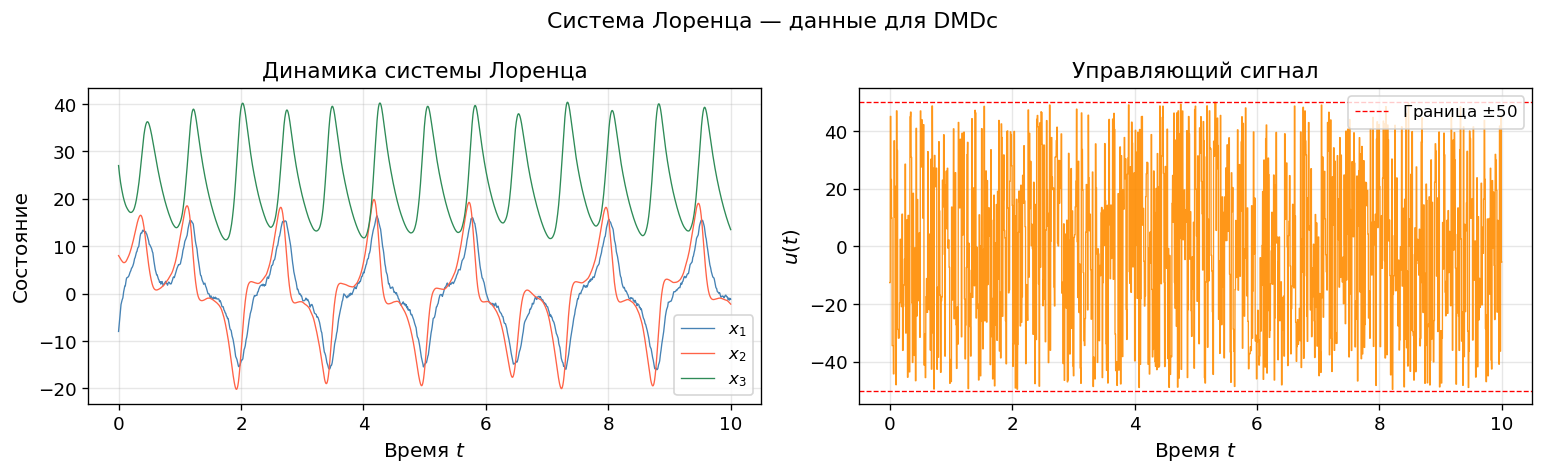

In [95]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# ── График 1: компоненты во времени ───
axes[0].plot(t_eval_lor, sol_lor.y[0], lw=0.8,
             color='steelblue', label='$x_1$')
axes[0].plot(t_eval_lor, sol_lor.y[1], lw=0.8,
             color='tomato', label='$x_2$')
axes[0].plot(t_eval_lor, sol_lor.y[2], lw=0.8,
             color='seagreen', label='$x_3$')
axes[0].set_xlabel('Время $t$')
axes[0].set_ylabel('Состояние')
axes[0].set_title('Динамика системы Лоренца')
axes[0].legend()

# ── График 2: управляющий сигнал ───
axes[1].plot(t_eval_lor[:-1], U_lor[0],
             lw=0.8, color='darkorange', alpha=0.9)
axes[1].axhline(y= 50, color='red', lw=0.8, ls='--',
                label='Граница $\\pm 50$')
axes[1].axhline(y=-50, color='red', lw=0.8, ls='--')
axes[1].set_xlabel('Время $t$')
axes[1].set_ylabel('$u(t)$')
axes[1].set_title('Управляющий сигнал')
axes[1].legend()

plt.suptitle(
    'Система Лоренца — данные для DMDc'
)
plt.tight_layout()
#plt.savefig('figures/lorenz_data.png', dpi=150, bbox_inches='tight')
plt.show()

## Шаг 2. Стандартный DMDc — Algorithm 1 

Реализуем класс `StandardDMDc`.

**Вход:** матрицы снимков $X$, $X'$, $\Upsilon$ и параметры ранга $p$, $r$.

**Выход:** редуцированные операторы $\tilde{A}$, $\tilde{B}$,
собственные значения $\Lambda$, DMD-моды $\Phi$.

**Ключевые шаги:**
1. Truncated SVD матрицы $\Omega = [X;\,\Upsilon]$ с рангом $p$
2. Truncated SVD матрицы $X'$ с рангом $r$
3. Вычисление $\tilde{A}$ и $\tilde{B}$ через проекцию
4. Eigendecomposition $\tilde{A}$
5. Перевод мод в полное пространство

In [96]:
class StandardDMDc:
    """
    Стандартный алгоритм DMDc.

    Parameters
    ----------
    p : Ранг усечения SVD матрицы Omega (входное пространство).
    r : Ранг усечения SVD матрицы X' (выходное пространство).
    """

    def __init__(self, p: int, r: int):
        self.p = p
        self.r = r
        self._A_tilde     = None   # редуцированный оператор A (r×r)
        self._B_tilde     = None   # редуцированный оператор B (r×l)
        self._eigenvalues = None   # собственные значения Lambda
        self._modes       = None   # DMD-моды Phi (n×r)
        self._U_hat       = None   # базис выходного пространства (n×r)

    # ──────────────────────────────────────────────────────────────
    def fit(self, X: np.ndarray, Xp: np.ndarray, U: np.ndarray):
        """
        Обучение модели по матрицам снимков.

        Parameters
        ----------
        X  : (n, m) — состояния "сейчас"
        Xp : (n, m) — состояния "потом"
        U  : (l, m) — управление
        """
        n, m = X.shape
        l    = U.shape[0]

        # ── Шаг 1. SVD матрицы Omega с рангом p ───────────────────
        Omega = np.vstack([X, U])                    # (n+l, m)
        U_tilde, S_tilde, Vt_tilde = np.linalg.svd(Omega, full_matrices=False)
        
        # Усечение до ранга p
        U_tilde = U_tilde[:, :self.p]                # (n+l, p)
        S_tilde = S_tilde[:self.p]                   # (p,)
        Vt_tilde = Vt_tilde[:self.p, :]              # (p, m)

        # Разбиваем U_tilde на два блока
        U1_tilde = U_tilde[:n, :]                    # (n, p) — блок состояний
        U2_tilde = U_tilde[n:, :]                    # (l, p) — блок управления

        # ── Шаг 2. SVD матрицы X' с рангом r ──────────────────────
        U_hat, S_hat, Vt_hat = np.linalg.svd(Xp, full_matrices=False)

        # Усечение до ранга r
        U_hat  = U_hat[:, :self.r]                   # (n, r)
        S_hat  = S_hat[:self.r]                      # (r,)
        Vt_hat = Vt_hat[:self.r, :]                  # (r, m)

        self._U_hat = U_hat

        # ── Шаг 3. Редуцированные операторы A и B ─────────────────
        # Общий блок: Xp @ Vt_tilde.T @ diag(1/S_tilde)
        core = Xp @ Vt_tilde.T @ np.diag(1.0 / S_tilde)   # (n, p)

        self._A_tilde = U_hat.conj().T @ core @ U1_tilde.conj().T @ U_hat  # (r, r)
        self._B_tilde = U_hat.conj().T @ core @ U2_tilde.conj().T          # (r, l)

        # ── Шаг 4. Eigendecomposition редуцированного A ────────────
        eigenvalues, W = np.linalg.eig(self._A_tilde)
        self._eigenvalues = eigenvalues                       # (r,)

        # ── Шаг 5. DMD-моды в полном пространстве ─────────────────
        self._modes = core @ U1_tilde.conj().T @ U_hat @ W          # (n, r)

        return self

    # ──────────────────────────────────────────────────────────────
    def predict(self, x0: np.ndarray, U_future: np.ndarray) -> np.ndarray:
        """
        Прогноз состояния на несколько шагов вперёд.

        Parameters
        ----------
        x0       : (n,)    — начальное состояние
        U_future : (l, T)  — управление на T шагов

        Returns
        -------
        X_pred : (n, T+1)  — прогноз состояний
        """
        T = U_future.shape[1]
        n = x0.shape[0]

        X_pred = np.zeros((n, T + 1))
        X_pred[:, 0] = x0

        # Проецируем начальное состояние в редуцированное пространство
        z = self._U_hat.conj().T @ x0                         # (r,)

        for k in range(T):
            u_k = U_future[:, k]
            z  = self._A_tilde @ z + self._B_tilde @ u_k
            X_pred[:, k + 1] = (self._U_hat @ z).real    
        return X_pred

    # ──────────────────────────────────────────────────────────────
    @property
    def A(self) -> np.ndarray:
        """Редуцированная матрица динамики (r×r)."""
        return self._A_tilde

    @property
    def B(self) -> np.ndarray:
        """Редуцированная матрица управления (r×l)."""
        return self._B_tilde

    @property
    def eigenvalues(self) -> np.ndarray:
        """Собственные значения DMD."""
        return self._eigenvalues

    @property
    def modes(self) -> np.ndarray:
        """DMD-моды Phi в полном пространстве (n×r)."""
        return self._modes

### StandardDMDc — Лотка–Вольтерра

In [97]:
# ── Создаём и обучаем модель ───────────────────────────────────────
model_std_lv = StandardDMDc(p=3, r=2)
model_std_lv.fit(X_lv, Xp_lv, U_lv)

print("StandardDMDc — Лотка–Вольтерра")
print("─" * 40)

print(f"\nРедуцированная A {model_std_lv.A.shape}:")
print(np.round(model_std_lv.A, 4))

print(f"\nРедуцированная B {model_std_lv.B.shape}:")
print(np.round(model_std_lv.B, 4))

print(f"\nСобственные значения:")
for i, lam in enumerate(model_std_lv.eigenvalues):
    print(f"  ω{i+1} = {lam:.4f}")

StandardDMDc — Лотка–Вольтерра
────────────────────────────────────────

Редуцированная A (2, 2):
[[ 9.982e-01  1.054e-01]
 [-6.000e-04  9.903e-01]]

Редуцированная B (2, 1):
[[-0.2093]
 [ 0.0175]]

Собственные значения:
  ω1 = 0.9943+0.0066j
  ω2 = 0.9943-0.0066j


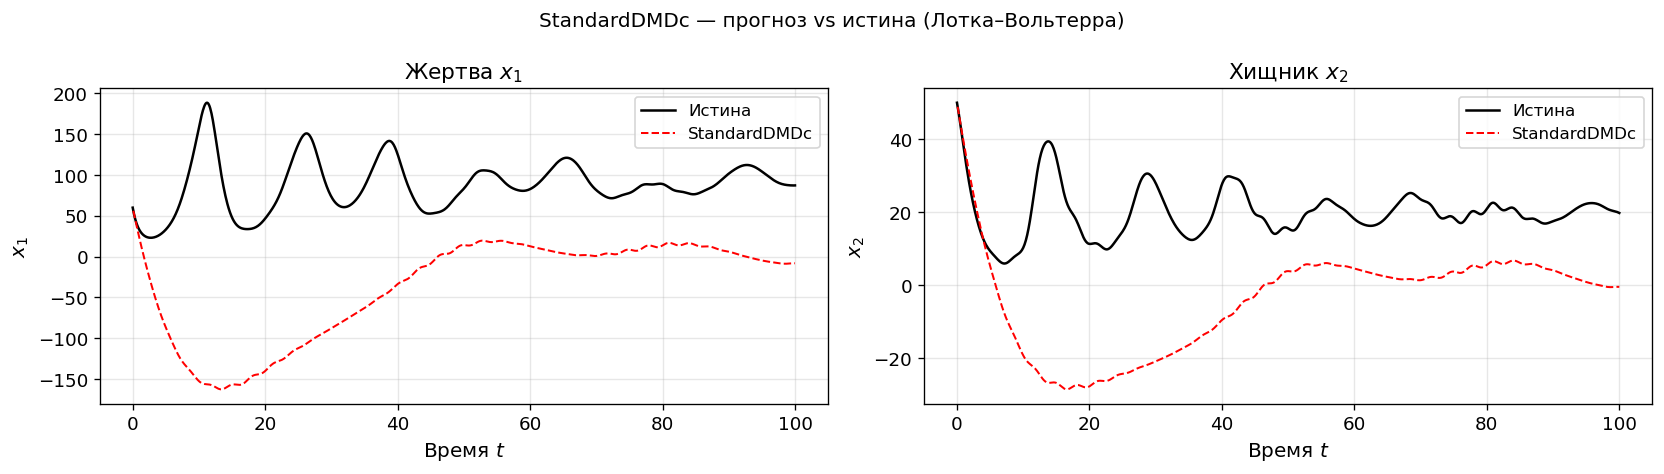

In [98]:
# ── Прогноз ───────────────────────────────────────────────────────
X_pred_std = model_std_lv.predict(
    x0       = X_lv[:, 0],
    U_future = U_lv
)

# ── График ────────────────────────────────────────────────────────
t_lv = np.linspace(0, 100, 1001)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Компонента x1
axes[0].plot(t_lv, sol_lv.y[0], 'k-',  lw=1.5, label='Истина')
axes[0].plot(t_lv[1:], X_pred_std[0, 1:], 'r--', lw=1.2,
             label='StandardDMDc')
axes[0].set_xlabel('Время $t$')
axes[0].set_ylabel('$x_1$')
axes[0].set_title('Жертва $x_1$')
axes[0].legend()

# Компонента x2
axes[1].plot(t_lv, sol_lv.y[1], 'k-',  lw=1.5, label='Истина')
axes[1].plot(t_lv[1:], X_pred_std[1, 1:], 'r--', lw=1.2,
             label='StandardDMDc')
axes[1].set_xlabel('Время $t$')
axes[1].set_ylabel('$x_2$')
axes[1].set_title('Хищник $x_2$')
axes[1].legend()

plt.suptitle('StandardDMDc — прогноз vs истина (Лотка–Вольтерра)',
             fontsize=12)
plt.tight_layout()
#plt.savefig('figures/lv_standard_pred.png', dpi=150, bbox_inches='tight')
plt.show()


## Шаг 3. Улучшенный DMDc — Algorithm 3 (из статьи)

Ключевое улучшение над Algorithm 1: вместо SVD матрицы $X'$ размером
$n\times m$ делаем SVD матрицы $\tilde{H} = \tilde{\Sigma}^{-1}\tilde{U}_1^*$
размером $p\times n$, где $p \ll m$.

Это даёт:
- Меньше вычислений на шаге 3
- Более простые формулы для $\tilde{A}$, $\tilde{B}$, $\Phi$
- Идентичные результаты по собственным значениям и модам

In [99]:
class ImprovedDMDc:
    """
    Улучшенный алгоритм DMDc (Algorithm 3, Nedzhibov, 2023).

    Parameters
    ----------
    p : int — ранг усечения SVD матрицы Omega
    r : int — ранг усечения SVD матрицы H_tilde
    """

    def __init__(self, p: int, r: int):
        self.p = p
        self.r = r

        self._A_tilde     = None
        self._B_tilde     = None
        self._eigenvalues = None
        self._modes       = None
        self._V_check     = None   # базис проекции (n×r) — вместо U_hat

    # ──────────────────────────────────────────────────────────────
    def fit(self, X: np.ndarray, Xp: np.ndarray, U: np.ndarray):
        """
        Обучение модели.

        Parameters
        ----------
        X  : (n, m) — состояния "сейчас"
        Xp : (n, m) — состояния "потом"
        U  : (l, m) — управление
        """
        n, m = X.shape
        l    = U.shape[0]

        # ── Шаг 1. SVD матрицы Omega с рангом p ───────────────────
        Omega = np.vstack([X, U])                      # (n+l, m)
        U_tilde, S_tilde, Vt_tilde = np.linalg.svd(Omega, full_matrices=False)

        U_tilde  = U_tilde[:, :self.p]                 # (n+l, p)
        S_tilde  = S_tilde[:self.p]                    # (p,)
        Vt_tilde = Vt_tilde[:self.p, :]                # (p, m)
        V_tilde  = Vt_tilde.T                          # (m, p)

        U1_tilde = U_tilde[:n, :]                      # (n, p)
        U2_tilde = U_tilde[n:, :]                      # (l, p)

        # ── Шаг 2. Блоки псевдообратной Omega ─────────────────────
        Sigma_inv = np.diag(1.0 / S_tilde)             # (p, p)
        Omega2    = V_tilde @ Sigma_inv @ U2_tilde.T   # (m, l)

        # ── Шаг 3. SVD матрицы H_tilde = Sigma^{-1} U1* ──────────
        # H_tilde имеет размер (p, n) — намного меньше чем (n, m)!
        H_tilde = Sigma_inv @ U1_tilde.T               # (p, n)

        U_bar, S_check, Vt_check = np.linalg.svd(H_tilde, full_matrices=False)

        U_bar    = U_bar[:, :self.r]                   # (p, r)
        S_check  = S_check[:self.r]                    # (r,)
        Vt_check = Vt_check[:self.r, :]                # (r, n)
        V_check  = Vt_check.T                          # (n, r)

        self._V_check = V_check

        # Восстанавливаем U_check = V_tilde @ U_bar
        U_check = V_tilde @ U_bar                      # (m, r)

        # ── Шаг 4. Редуцированные матрицы A и B ───────────────────
        # Общий блок: Xp @ U_check @ diag(S_check)
        core_imp = Xp @ U_check @ np.diag(S_check)    # (n, r)

        self._A_tilde = Vt_check @ core_imp            # (r, r)
        self._B_tilde = Vt_check @ Xp @ Omega2        # (r, l)

        # ── Шаг 5. Eigendecomposition ──────────────────────────────
        eigenvalues, W = np.linalg.eig(self._A_tilde)
        self._eigenvalues = eigenvalues                # (r,)

        # ── Шаг 6. DMD-моды ────────────────────────────────────────
        self._modes = core_imp @ W                     # (n, r)

        return self

    # ──────────────────────────────────────────────────────────────
    def predict(self, x0: np.ndarray, U_future: np.ndarray) -> np.ndarray:
        """
        Прогноз состояния.

        Parameters
        ----------
        x0       : (n,)   — начальное состояние
        U_future : (l, T) — управление на T шагов

        Returns
        -------
        X_pred : (n, T+1)
        """
        T = U_future.shape[1]
        n = x0.shape[0]

        X_pred = np.zeros((n, T + 1))
        X_pred[:, 0] = x0

        # Проецируем в редуцированное пространство через V_check
        z = self._V_check.conj().T @ x0                        # (r,)

        for k in range(T):
            u_k = U_future[:, k]
            z   = self._A_tilde @ z + self._B_tilde @ u_k
            X_pred[:, k + 1] = (self._V_check @ z).real

        return X_pred

    # ──────────────────────────────────────────────────────────────
    @property
    def A(self) -> np.ndarray:
        return self._A_tilde

    @property
    def B(self) -> np.ndarray:
        return self._B_tilde

    @property
    def eigenvalues(self) -> np.ndarray:
        return self._eigenvalues

    @property
    def modes(self) -> np.ndarray:
        return self._modes

In [100]:
# ── Создаём и обучаем модель ───────────────────────────────────────
model_imp_lv = ImprovedDMDc(p=3, r=2)
model_imp_lv.fit(X_lv, Xp_lv, U_lv)

print("ImprovedDMDc — Лотка–Вольтерра")
print("─" * 40)
print(f"\nРедуцированная A {model_imp_lv.A.shape}:")
print(np.round(model_imp_lv.A, 4))
print(f"\nРедуцированная B {model_imp_lv.B.shape}:")
print(np.round(model_imp_lv.B, 4))
print(f"\nСобственные значения:")
for i, lam in enumerate(model_imp_lv.eigenvalues):
    print(f"  ω{i+1} = {lam:.4f}")
print("─" * 40)
print("Сравнение собственных значений:")
print(f"  Standard:  {[f'{e:.4f}' for e in model_std_lv.eigenvalues]}")
print(f"  Improved:  {[f'{e:.4f}' for e in model_imp_lv.eigenvalues]}")
print(f"  Статья:    ω1=0.9680, ω2=1.0094")

ImprovedDMDc — Лотка–Вольтерра
────────────────────────────────────────

Редуцированная A (2, 2):
[[ 9.885e-01 -7.000e-04]
 [ 1.052e-01  1.000e+00]]

Редуцированная B (2, 1):
[[ 0.021]
 [-0.209]]

Собственные значения:
  ω1 = 0.9943+0.0066j
  ω2 = 0.9943-0.0066j
────────────────────────────────────────
Сравнение собственных значений:
  Standard:  ['0.9943+0.0066j', '0.9943-0.0066j']
  Improved:  ['0.9943+0.0066j', '0.9943-0.0066j']
  Статья:    ω1=0.9680, ω2=1.0094


In [101]:
# ── RMSE для финальных параметров ─────────────────────────────────
def compute_rmse(X_true, X_pred):
    """RMSE по формуле из статьи (29):
    RMSE(i) = sqrt(1/n * sum(x_i(s) - x_hat_i(s))^2)
    """
    rmse = []
    for i in range(X_true.shape[0]):
        rmse.append(np.sqrt(np.mean((X_true[i] - X_pred[i])**2)))
    return rmse

# Параметры как в нашем проекте
p_rank, r_rank = 3, 2

model_std_lv = StandardDMDc(p=p_rank, r=r_rank)
model_std_lv.fit(X_lv, Xp_lv, U_lv)
Xp_std = model_std_lv.predict(X_lv[:, 0], U_lv)[:, 1:]

model_imp_lv = ImprovedDMDc(p=p_rank, r=r_rank)
model_imp_lv.fit(X_lv, Xp_lv, U_lv)
Xp_imp = model_imp_lv.predict(X_lv[:, 0], U_lv)[:, 1:]

rmse_std = compute_rmse(Xp_lv, Xp_std)
rmse_imp = compute_rmse(Xp_lv, Xp_imp)

print("RMSE — Лотка–Вольтерра (p=3, r=2)")
print("─" * 45)
print(f"{'':20} {'Standard':>10} {'Improved':>10}")
print(f"{'RMSE(x1)':20} {rmse_std[0]:>10.2f} {rmse_imp[0]:>10.2f}")
print(f"{'RMSE(x2)':20} {rmse_std[1]:>10.2f} {rmse_imp[1]:>10.2f}")
print()
print("RMSE из статьи:")
print(f"{'RMSE(x1)':20} {'12276':>10} {'393':>10}")
print(f"{'RMSE(x2)':20} {'8204':>10} {'420':>10}")

RMSE — Лотка–Вольтерра (p=3, r=2)
─────────────────────────────────────────────
                       Standard   Improved
RMSE(x1)                 142.45     142.45
RMSE(x2)                  28.23      28.23

RMSE из статьи:
RMSE(x1)                  12276        393
RMSE(x2)                   8204        420


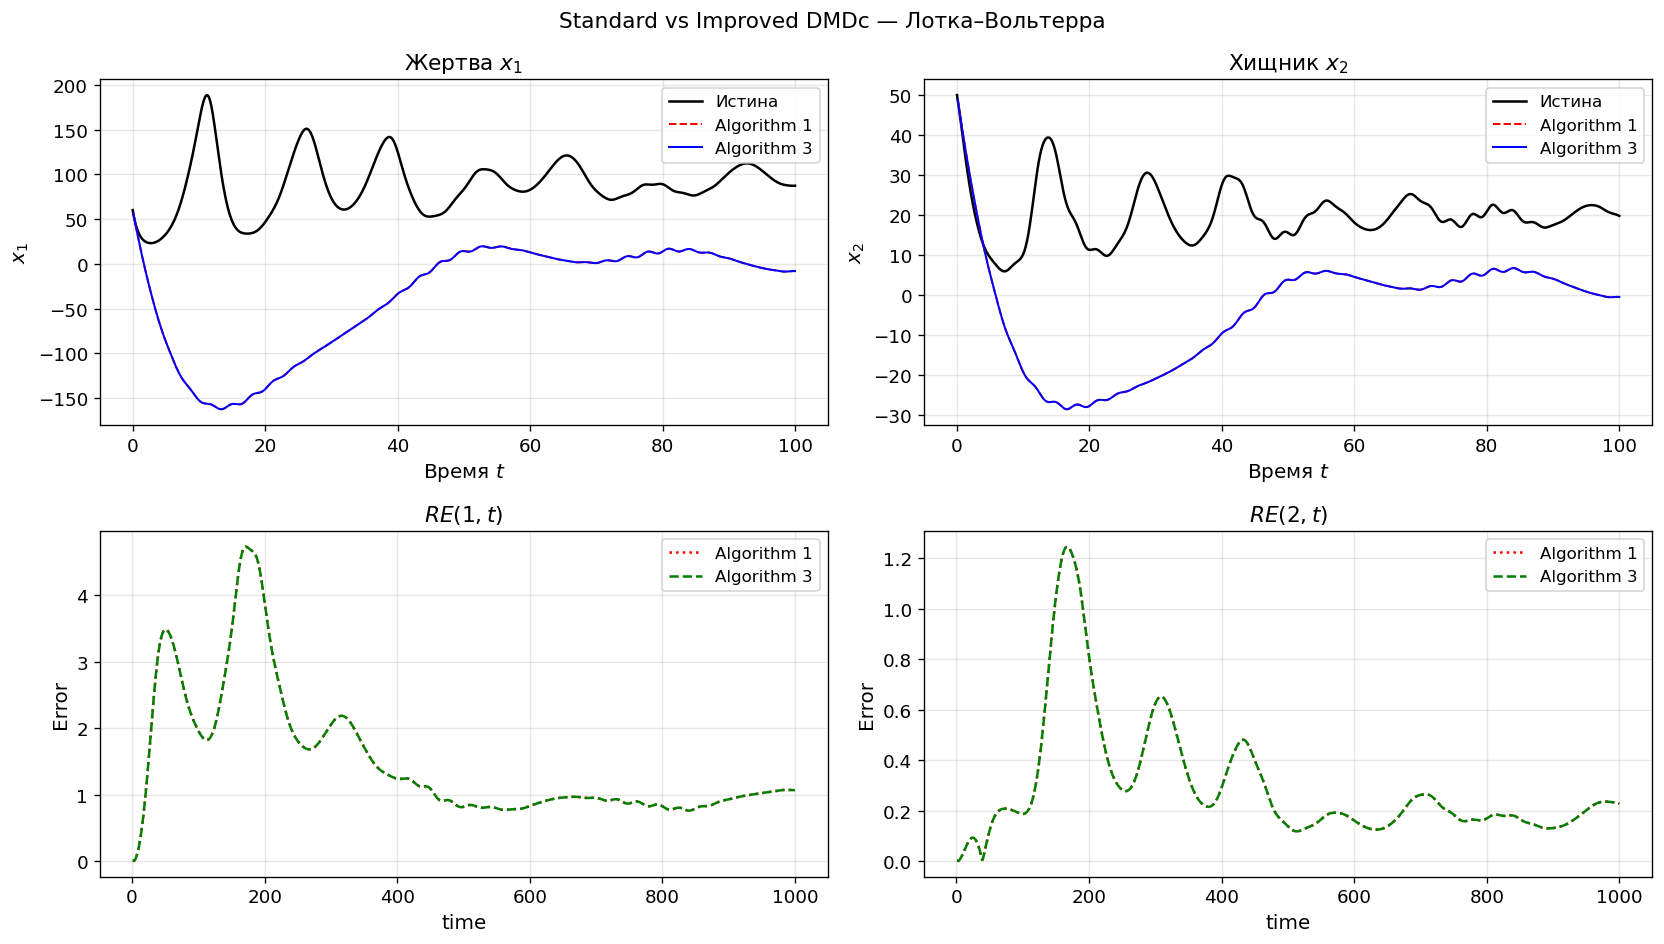

In [102]:
# ── Прогнозы ──────────────────────────────────────────────────────
X_pred_std = model_std_lv.predict(x0=X_lv[:, 0], U_future=U_lv)
X_pred_imp = model_imp_lv.predict(x0=X_lv[:, 0], U_future=U_lv)

Xp_std = X_pred_std[:, 1:]   # (2, 1000)
Xp_imp = X_pred_imp[:, 1:]   # (2, 1000)

t_lv   = np.linspace(0, 100, 1001)
t_snap = np.arange(1, 1001)   # номера снимков 1..1000 как в статье

# ── RE по компонентам (формула 30 из статьи) ──────────────────────
true_norm = np.linalg.norm(Xp_lv, axis=0)   # ||x(t)|| в каждый момент

def re_component(x_true_i, x_pred_i, norm):
    """RE(i,t) = |xi_true - xi_pred| / ||x_true||"""
    return np.abs(x_true_i - x_pred_i) / (norm + 1e-10)

RE_std_1 = re_component(Xp_lv[0], Xp_std[0], true_norm)
RE_std_2 = re_component(Xp_lv[1], Xp_std[1], true_norm)
RE_imp_1 = re_component(Xp_lv[0], Xp_imp[0], true_norm)
RE_imp_2 = re_component(Xp_lv[1], Xp_imp[1], true_norm)

# ── Один холст 2×2 ────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# ── График 1: x1 ──────────────────────────────────────────────────
axes[0, 0].plot(t_lv,     sol_lv.y[0],       'k-',  lw=1.5, label='Истина')
axes[0, 0].plot(t_lv[1:], Xp_std[0],         'r--', lw=1.2, label='Algorithm 1')
axes[0, 0].plot(t_lv[1:], Xp_imp[0],         'b-',  lw=1.2, label='Algorithm 3')
axes[0, 0].set_title('Жертва $x_1$')
axes[0, 0].set_xlabel('Время $t$')
axes[0, 0].set_ylabel('$x_1$')
axes[0, 0].legend()

# ── График 2: x2 ──────────────────────────────────────────────────
axes[0, 1].plot(t_lv,     sol_lv.y[1],       'k-',  lw=1.5, label='Истина')
axes[0, 1].plot(t_lv[1:], Xp_std[1],         'r--', lw=1.2, label='Algorithm 1')
axes[0, 1].plot(t_lv[1:], Xp_imp[1],         'b-',  lw=1.2, label='Algorithm 3')
axes[0, 1].set_title('Хищник $x_2$')
axes[0, 1].set_xlabel('Время $t$')
axes[0, 1].set_ylabel('$x_2$')
axes[0, 1].legend()

# ── График 3: RE(x1) ──────────────────────────────────────────────
axes[1, 0].plot(t_snap, RE_std_1, 'r:',  lw=1.5, label='Algorithm 1')
axes[1, 0].plot(t_snap, RE_imp_1, 'g--', lw=1.5, label='Algorithm 3')
axes[1, 0].set_title('$RE(1, t)$')
axes[1, 0].set_xlabel('time')
axes[1, 0].set_ylabel('Error')
axes[1, 0].legend()

# ── График 4: RE(x2) ──────────────────────────────────────────────
axes[1, 1].plot(t_snap, RE_std_2, 'r:',  lw=1.5, label='Algorithm 1')
axes[1, 1].plot(t_snap, RE_imp_2, 'g--', lw=1.5, label='Algorithm 3')
axes[1, 1].set_title('$RE(2, t)$')
axes[1, 1].set_xlabel('time')
axes[1, 1].set_ylabel('Error')
axes[1, 1].legend()

plt.suptitle('Standard vs Improved DMDc — Лотка–Вольтерра', fontsize=13)
plt.tight_layout()
#plt.savefig('figures/lv_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Шаг 4. DMDc для системы Лоренца

Применяем оба алгоритма к хаотической системе Лоренца.

**Параметры:**
- $n = 3$ — размерность состояния
- $m = 10000$ — число снимков
- $l = 1$ — размерность управления
- $p = n + l = 4$ — максимальный ранг $\Omega$
- $r = n = 3$ — полный ранг состояния

In [103]:
p_lor = 4   # n + l = 3 + 1
r_lor = 3   # n = 3

# ── Обучение ───────────────────────────────────────────────────────
model_std_lor = StandardDMDc(p=p_lor, r=r_lor)
model_std_lor.fit(X_lor, Xp_lor, U_lor)

model_imp_lor = ImprovedDMDc(p=p_lor, r=r_lor)
model_imp_lor.fit(X_lor, Xp_lor, U_lor)

print("Система Лоренца — результаты обучения")
print("─" * 45)
print(f"\nСобственные значения Standard DMDc:")
for i, lam in enumerate(model_std_lor.eigenvalues):
    print(f"  λ{i+1} = {lam:.6f}  |λ| = {abs(lam):.6f}")

print(f"\nСобственные значения Improved DMDc:")
for i, lam in enumerate(model_imp_lor.eigenvalues):
    print(f"  λ{i+1} = {lam:.6f}  |λ| = {abs(lam):.6f}")

print(f"\nРазница собственных значений:")
diff = np.max(np.abs(
    np.sort(np.abs(model_std_lor.eigenvalues)) -
    np.sort(np.abs(model_imp_lor.eigenvalues))
))
print(f"  max|λ_std - λ_imp| = {diff:.2e}")

Система Лоренца — результаты обучения
─────────────────────────────────────────────

Собственные значения Standard DMDc:
  λ1 = 0.999955+0.000000j  |λ| = 0.999955
  λ2 = 0.999582+0.005580j  |λ| = 0.999597
  λ3 = 0.999582-0.005580j  |λ| = 0.999597

Собственные значения Improved DMDc:
  λ1 = 0.999582+0.005580j  |λ| = 0.999597
  λ2 = 0.999582-0.005580j  |λ| = 0.999597
  λ3 = 0.999955+0.000000j  |λ| = 0.999955

Разница собственных значений:
  max|λ_std - λ_imp| = 5.55e-16


In [104]:
# ── Прогноз ───────────────────────────────────────────────────────
X_pred_std_lor = model_std_lor.predict(x0=X_lor[:, 0], U_future=U_lor)
X_pred_imp_lor = model_imp_lor.predict(x0=X_lor[:, 0], U_future=U_lor)

Xp_std_lor = X_pred_std_lor[:, 1:]   # (3, 10000)
Xp_imp_lor = X_pred_imp_lor[:, 1:]   # (3, 10000)

# ── RMSE ──────────────────────────────────────────────────────────
rmse_std_lor = compute_rmse(Xp_lor, Xp_std_lor)
rmse_imp_lor = compute_rmse(Xp_lor, Xp_imp_lor)

print("RMSE — система Лоренца (p=4, r=3)")
print("─" * 45)
print(f"{'':20} {'Standard':>10} {'Improved':>10}")
print(f"{'RMSE(x1)':20} {rmse_std_lor[0]:>10.2f} {rmse_imp_lor[0]:>10.2f}")
print(f"{'RMSE(x2)':20} {rmse_std_lor[1]:>10.2f} {rmse_imp_lor[1]:>10.2f}")
print(f"{'RMSE(x3)':20} {rmse_std_lor[2]:>10.2f} {rmse_imp_lor[2]:>10.2f}")

RMSE — система Лоренца (p=4, r=3)
─────────────────────────────────────────────
                       Standard   Improved
RMSE(x1)                  11.49      11.49
RMSE(x2)                  13.05      13.05
RMSE(x3)                   9.35       9.35


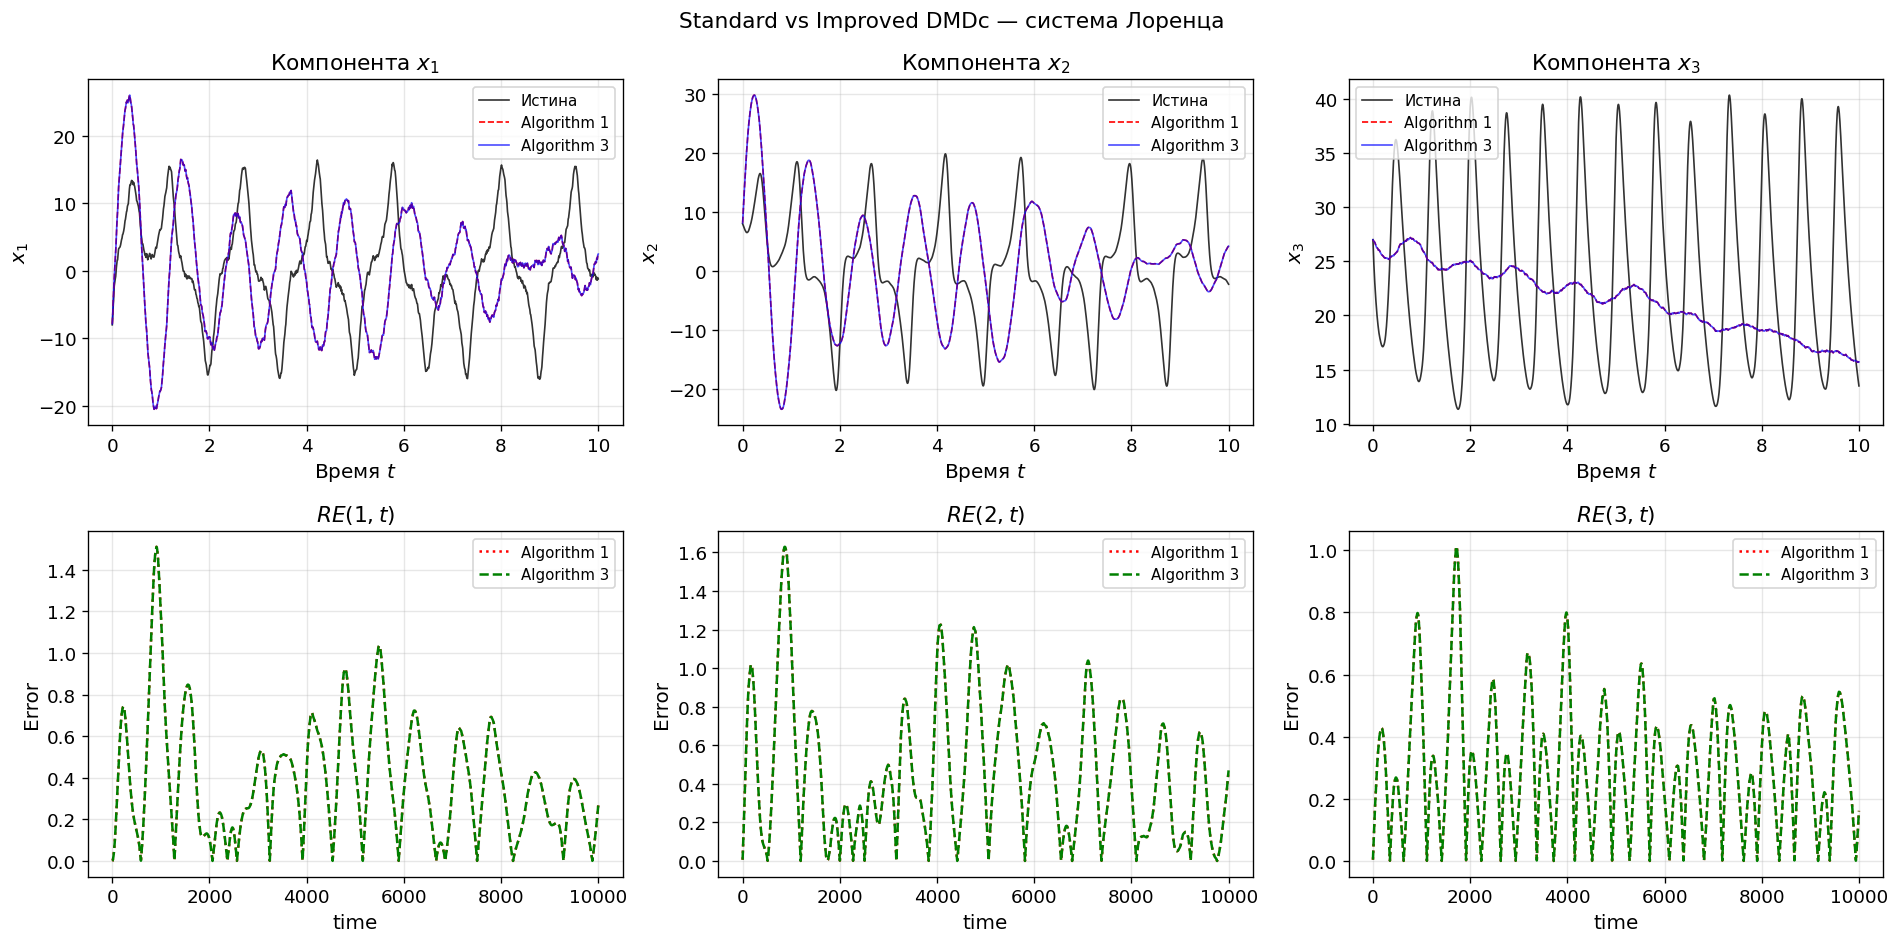

In [105]:
t_lor  = np.linspace(0, t_end_lor, 10001)
t_snap_lor = np.arange(1, 10001)

# ── RE ──
true_norm_lor = np.linalg.norm(Xp_lor, axis=0)

def re_component(x_true_i, x_pred_i, norm):
    return np.abs(x_true_i - x_pred_i) / (norm + 1e-10)

RE_std_lor = [re_component(Xp_lor[i], Xp_std_lor[i], true_norm_lor)
              for i in range(3)]
RE_imp_lor = [re_component(Xp_lor[i], Xp_imp_lor[i], true_norm_lor)
              for i in range(3)]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
labels   = ['$x_1$', '$x_2$', '$x_3$']
colors_t = ['steelblue', 'tomato', 'seagreen']

# Верхний ряд: прогноз vs истина
for i in range(3):
    axes[0, i].plot(t_lor,     sol_lor.y[i],        'k-',  lw=1.0,
                    label='Истина', alpha=0.8)
    axes[0, i].plot(t_lor[1:], Xp_std_lor[i],       'r--', lw=1.0,
                    label='Algorithm 1')
    axes[0, i].plot(t_lor[1:], Xp_imp_lor[i],       'b-',  lw=1.0,
                    label='Algorithm 3', alpha=0.7)
    axes[0, i].set_title(f'Компонента {labels[i]}')
    axes[0, i].set_xlabel('Время $t$')
    axes[0, i].set_ylabel(labels[i])
    axes[0, i].legend(fontsize=9)

# Нижний ряд: RE по компонентам
for i in range(3):
    axes[1, i].plot(t_snap_lor, RE_std_lor[i], 'r:', lw=1.5,
                    label='Algorithm 1')
    axes[1, i].plot(t_snap_lor, RE_imp_lor[i], 'g--', lw=1.5,
                    label='Algorithm 3')
    axes[1, i].set_title(f'$RE({i+1}, t)$')
    axes[1, i].set_xlabel('time')
    axes[1, i].set_ylabel('Error')
    axes[1, i].legend(fontsize=9)

plt.suptitle('Standard vs Improved DMDc — система Лоренца', fontsize=13)
plt.tight_layout()
#plt.savefig('figures/lorenz_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

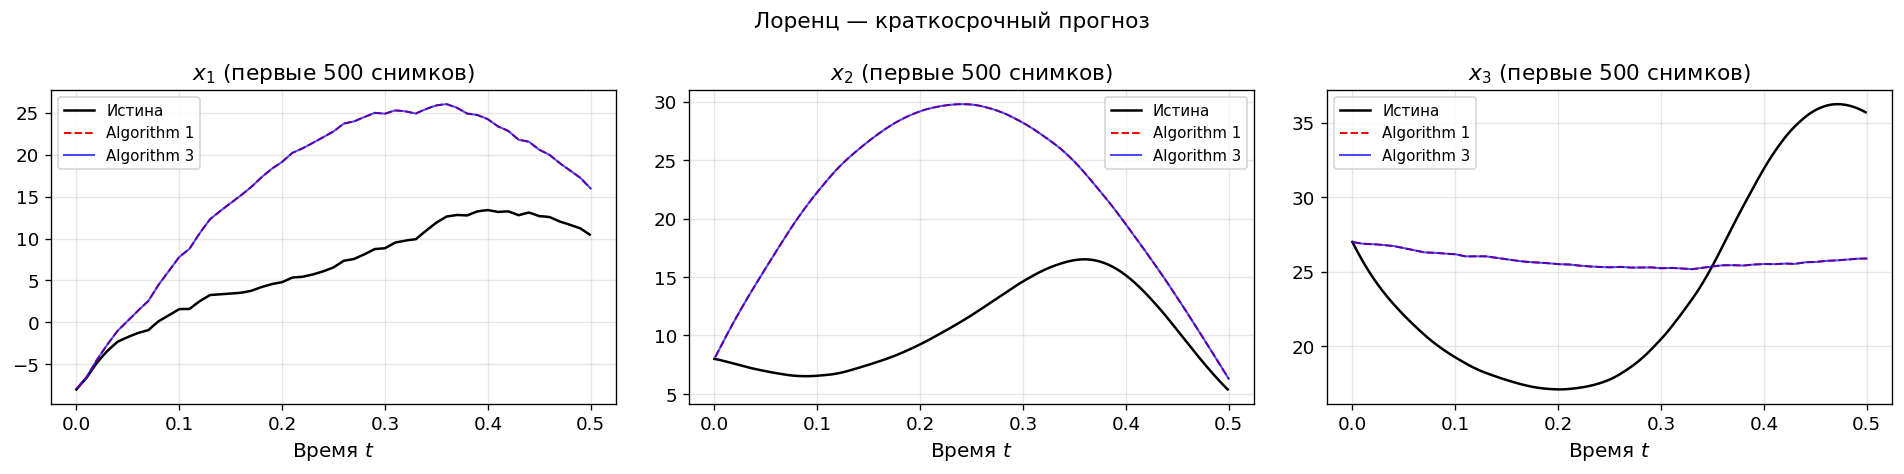

In [106]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
T_show = 500   # только первые 500 снимков

for i in range(3):
    axes[i].plot(t_lor[:T_show],     sol_lor.y[i, :T_show],
                 'k-', lw=1.5, label='Истина')
    axes[i].plot(t_lor[1:T_show+1],  Xp_std_lor[i, :T_show],
                 'r--', lw=1.2, label='Algorithm 1')
    axes[i].plot(t_lor[1:T_show+1],  Xp_imp_lor[i, :T_show],
                 'b-', lw=1.2, label='Algorithm 3', alpha=0.7)
    axes[i].set_title(f'$x_{i+1}$ (первые {T_show} снимков)')
    axes[i].set_xlabel('Время $t$')
    axes[i].legend(fontsize=9)

plt.suptitle('Лоренц — краткосрочный прогноз', fontsize=13)
plt.tight_layout()
#plt.savefig('figures/lorenz_short.png', dpi=150, bbox_inches='tight')
plt.show()

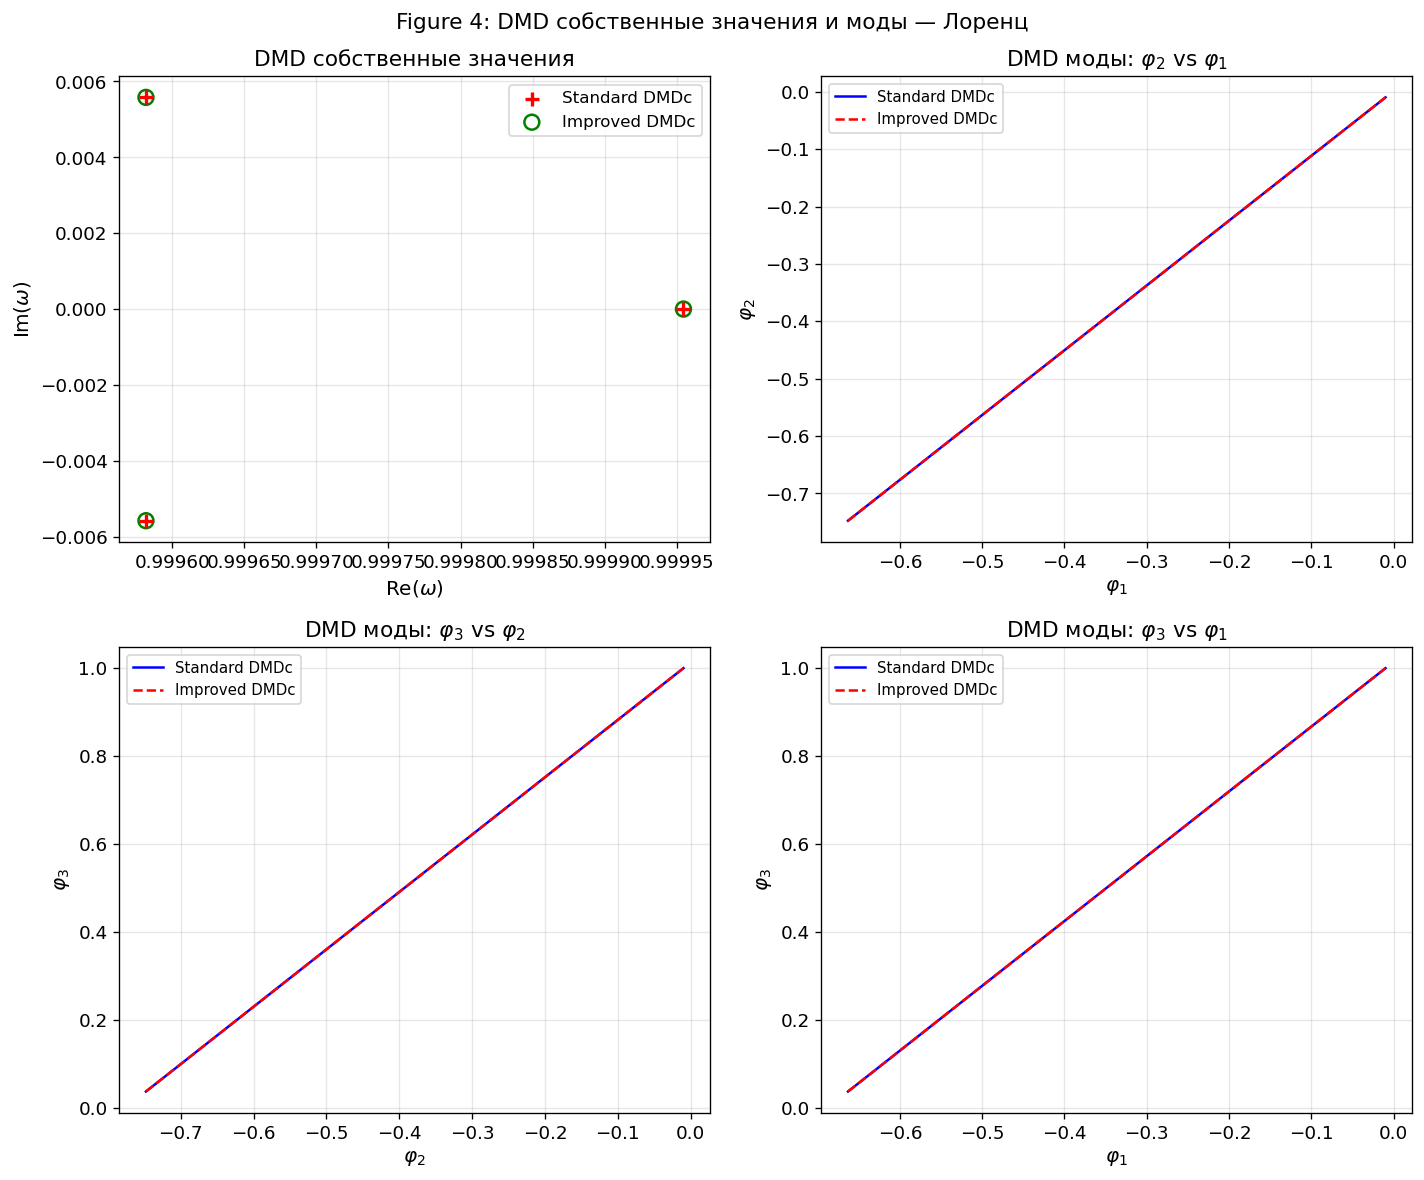

In [107]:
evals_std  = model_std_lor.eigenvalues
evals_imp  = model_imp_lor.eigenvalues
modes_std  = model_std_lor.modes       # (3, 3) — 3 компоненты × 3 моды
modes_imp  = model_imp_lor.modes       # (3, 3)

# ── Нормировка мод ─────────────────────────────────────────────────
def normalize_modes(modes):
    return modes / np.linalg.norm(modes, axis=0, keepdims=True)

modes_std_n = normalize_modes(modes_std.real)   # (3, 3)
modes_imp_n = normalize_modes(modes_imp.real)   # (3, 3)
# ── Выравниваем знаки мод ──────────────────────────────────────────
def align_modes(modes_ref, modes_target):
    """
    Выравниваем знаки мод target относительно ref.
    Если скалярное произведение мод отрицательное — меняем знак.
    """
    modes_out = modes_target.copy()
    for m in range(modes_ref.shape[1]):
        dot = np.dot(modes_ref[:, m], modes_target[:, m])
        if dot < 0:
            modes_out[:, m] = -modes_target[:, m]
    return modes_out

modes_std_n = normalize_modes(modes_std.real)
modes_imp_n = normalize_modes(modes_imp.real)

# Выравниваем Improved относительно Standard
modes_imp_n = align_modes(modes_std_n, modes_imp_n)

# Сортируем по первой компоненте — для правильного соединения линией
idx_std = np.argsort(modes_std_n[0, :])
idx_imp = np.argsort(modes_imp_n[0, :])

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# ── График 1: собственные значения на комплексной плоскости ───────
ax = axes[0, 0]
ax.scatter(evals_std.real, evals_std.imag,
           color='red', s=80, marker='+',
           label='Standard DMDc', zorder=5, linewidths=2)
ax.scatter(evals_imp.real, evals_imp.imag,
           color='green', s=80, marker='o',
           facecolors='none', linewidths=1.5,
           label='Improved DMDc', zorder=4)
ax.set_xlabel('Re($\\omega$)')
ax.set_ylabel('Im($\\omega$)')
ax.set_title('DMD собственные значения')
ax.legend()
ax.grid(True, alpha=0.3)

# ── Графики 2-4: моды как линии ────────────────────────────────────
# В статье оси — φ1, φ2, φ3 (компоненты мод)
# Каждая линия соединяет три моды по порядку компонент
mode_plots = [
    (0, 1, 0, 1),   # φ2 vs φ1  → верхний правый
    (1, 2, 1, 0),   # φ3 vs φ2  → нижний левый
    (0, 2, 1, 1),   # φ3 vs φ1  → нижний правый
]

for ci, cj, row, col in mode_plots:
    ax = axes[row, col]

    ax.plot(modes_std_n[ci, idx_std], modes_std_n[cj, idx_std],
            'b-', lw=1.5, label='Standard DMDc')
    ax.plot(modes_imp_n[ci, idx_imp], modes_imp_n[cj, idx_imp],
            'r--', lw=1.5, label='Improved DMDc')

    ax.set_xlabel(f'$\\varphi_{ci+1}$')
    ax.set_ylabel(f'$\\varphi_{cj+1}$')
    ax.set_title(f'DMD моды: $\\varphi_{cj+1}$ vs $\\varphi_{ci+1}$')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle('Figure 4: DMD собственные значения и моды — Лоренц',
             fontsize=13)
plt.tight_layout()
#plt.savefig('figures/lorenz_modes.png', dpi=150, bbox_inches='tight')
plt.show()

In [108]:
import time

N = 50   # число прогонов для стабильного замера

t0 = time.perf_counter()
for _ in range(N):
    model_std_lor.fit(X_lor, Xp_lor, U_lor)
t_std = (time.perf_counter() - t0) / N

t0 = time.perf_counter()
for _ in range(N):
    model_imp_lor.fit(X_lor, Xp_lor, U_lor)
t_imp = (time.perf_counter() - t0) / N

print("Время выполнения fit() — система Лоренца")
print("─" * 40)
print(f"  Standard DMDc : {t_std*1000:.2f} мс")
print(f"  Improved DMDc : {t_imp*1000:.2f} мс")
print(f"  Speedup       : {t_std/t_imp:.2f}x")
print()

# Для сравнения — Лотка-Вольтерра
t0 = time.perf_counter()
for _ in range(N):
    model_std_lv.fit(X_lv, Xp_lv, U_lv)
t_std_lv = (time.perf_counter() - t0) / N

t0 = time.perf_counter()
for _ in range(N):
    model_imp_lv.fit(X_lv, Xp_lv, U_lv)
t_imp_lv = (time.perf_counter() - t0) / N

print("Время выполнения fit() — Лотка–Вольтерра")
print("─" * 40)
print(f"  Standard DMDc : {t_std_lv*1000:.2f} мс")
print(f"  Improved DMDc : {t_imp_lv*1000:.2f} мс")
print(f"  Speedup       : {t_std_lv/t_imp_lv:.2f}x")

Время выполнения fit() — система Лоренца
────────────────────────────────────────
  Standard DMDc : 1.66 мс
  Improved DMDc : 1.07 мс
  Speedup       : 1.54x

Время выполнения fit() — Лотка–Вольтерра
────────────────────────────────────────
  Standard DMDc : 0.12 мс
  Improved DMDc : 0.10 мс
  Speedup       : 1.19x
